# 2025 - 03 - 11 . Mulvirisk upload

## Summary

We aim to generate the records for each hit detected in McLeish 2024. To do so, we
need to obtain taxonomy ids for all the species considered in the study, and organize a table that contains:
- Plant species
- Virus OTU
- Location
- Date

In [45]:
import pandas as pd
import requests
import urllib
import difflib
import seaborn as sns 

## Loading the files

We load three files:
- McLeish Supplementary Table 4, which contains the viral OTUS -> `otu`
- McLeish Supplementary Table 2, which contains the library information -> `libraries`
- McLeish Supplementary Table 1, which contains the sampling information -> `sampling`

Additionally, we load a file provided by Fernando upon requests, which details in which samples were found each of the OTUs. 

In [2]:
otus = pd.read_csv("../data/mcleish2024/nph20054-sup-0002-TablesS4.csv", sep=';')
otus

,OTU name,Family,NCBI_title,OTU_reference,Genome,%_ID_mean,%_ID_min,%_ID_max,BLAST_matches,NCBI_accession
0,Alfamovirus 1,Bromoviridae,Alfalfa mosaic virus RNA 1,AMV1,(+)ssRNA,96.6,94.4,99.2,4.0,NC_001495
1,Alfamovirus 1,Bromoviridae,Alfalfa mosaic virus RNA 2,AMV2,(+)ssRNA,94.1,94.1,94.1,2.0,NC_002024
2,Alphaendornavirus 1,Endornaviridae,Cucumis melo endornavirus,CmEV,dsRNA,96.5,87.9,100.0,4174.0,NC_029064
3,Alphaendornavirus 2,Endornaviridae,Bell pepper endornavirus,BPEV,dsRNA,100.0,100.0,100.0,2.0,NC_015781
4,Alphaendornavirus 3,Endornaviridae,Hordeum vulgare endornavirus,HvEV,dsRNA,96.6,87.2,100.0,4002.0,NC_028949
...,...,...,...,...,...,...,...,...,...,...
173,Comovirus,Secoviridae,Arabidopsis latent virus-1 RNA2,ALaV2,(+)ssRNA,97.6,94.0,100.0,30.0,MH899121
174,Varicosavirus 1,Rhabdoviridae,Lettuce big-vein associated virus RNA 1,LBVaV1,(-)ssRNA,95.3,93.3,97.3,12.0,NC_011558
175,Varicosavirus 1,Rhabdoviridae,Lettuce big-vein associated virus RNA 2,LBVaV2,(-)ssRNA,94.9,90.6,98.0,32.0,NC_011568
176,Varicosavirus 2,Rhabdoviridae,Lettuce yellow mottle virus,LYMoV,(-)ssRNA,96.2,85.3,100.0,2702.0,NC_011532


OTUs have their NCBI accession, but not the Taxid accession, which might be an issue for future data points. Therefore, it might be good to search for taxon ids.

In [113]:
def extract_taxonomy_from_gene_records(host_name):
    url = "https://api.ncbi.nlm.nih.gov/datasets/v2"
    url = f'{url}/gene/accession/{host_name}/dataset_report'.replace(' ', '%20')
    r = requests.get(url)
    
    try: 
        r.raise_for_status()
    except requests.HTTPError:
        return pd.NA
    try:
        u = str(r.json()['reports'][0]['gene']['tax_id'])
    except KeyError:
        return pd.NA
    except IndexError:
        return pd.NA
    return u


In [115]:
otus['OTU_taxid'] = otus['NCBI_accession'].apply(extract_taxonomy_from_gene_records)

In [116]:
otus

,OTU name,Family,NCBI_title,OTU_reference,Genome,%_ID_mean,%_ID_min,%_ID_max,BLAST_matches,NCBI_accession,OTU_taxid
0,Alfamovirus 1,Bromoviridae,Alfalfa mosaic virus RNA 1,AMV1,(+)ssRNA,96.6,94.4,99.2,4.0,NC_001495,12321
1,Alfamovirus 1,Bromoviridae,Alfalfa mosaic virus RNA 2,AMV2,(+)ssRNA,94.1,94.1,94.1,2.0,NC_002024,12321
2,Alphaendornavirus 1,Endornaviridae,Cucumis melo endornavirus,CmEV,dsRNA,96.5,87.9,100.0,4174.0,NC_029064,1776177
3,Alphaendornavirus 2,Endornaviridae,Bell pepper endornavirus,BPEV,dsRNA,100.0,100.0,100.0,2.0,NC_015781,<NA>
4,Alphaendornavirus 3,Endornaviridae,Hordeum vulgare endornavirus,HvEV,dsRNA,96.6,87.2,100.0,4002.0,NC_028949,1774276
...,...,...,...,...,...,...,...,...,...,...,...
173,Comovirus,Secoviridae,Arabidopsis latent virus-1 RNA2,ALaV2,(+)ssRNA,97.6,94.0,100.0,30.0,MH899121,<NA>
174,Varicosavirus 1,Rhabdoviridae,Lettuce big-vein associated virus RNA 1,LBVaV1,(-)ssRNA,95.3,93.3,97.3,12.0,NC_011558,1985698
175,Varicosavirus 1,Rhabdoviridae,Lettuce big-vein associated virus RNA 2,LBVaV2,(-)ssRNA,94.9,90.6,98.0,32.0,NC_011568,1985698
176,Varicosavirus 2,Rhabdoviridae,Lettuce yellow mottle virus,LYMoV,(-)ssRNA,96.2,85.3,100.0,2702.0,NC_011532,471285


In [3]:
libraries = pd.read_csv("../data/mcleish2024/nph20054-sup-0002-TablesS2.csv", sep=';')

The sampling file has some issues, as wrong labels for seasons (e.g. November cannot be Summer in the Northern hemisphere). Besides, we have multiple sampling dates for some libraries. We will simplify the dataframe by grouping by Site codes and storing the dates in a list column.

In [4]:
sampling = pd.read_csv("../data/mcleish2024/nph20054-sup-0002-TablesS1.csv", sep=';')
sampling = sampling.groupby(['Site_code', 'Collection_code', 'Location', 'Longitude', 'Latitude'], as_index = False)['Date'].apply(list)
sampling

,Site_code,Collection_code,Location,Longitude,Latitude,Date
0,C1,C1F,Aranjuez,-3.593308,40.051302,[1/2/16]
1,C1,C3F,Aranjuez,-3.593308,40.051302,[30/1/17]
2,C2,C2F,Aranjuez,-3.599064,40.043193,[1/2/16]
3,C2,C4F,Aranjuez,-3.599064,40.043193,[30/1/17]
4,E1,E1F,Aranjuez,-3.500323,40.059138,"[19/11/15, 10/11/16]"
5,E1,E1P,Aranjuez,-3.500323,40.059138,"[23/5/16, 3/5/17]"
6,E2,E2F,San Martín de la Vega,-3.536191,40.234966,"[19/11/15, 10/11/16]"
7,E2,E2P,San Martín de la Vega,-3.536191,40.234966,"[23/5/16, 10/5/17]"
8,E3,E3F,Ambite,-3.196057,40.089637,"[1/2/16, 10/11/16]"
9,E3,E3P,Ambite,-3.196057,40.089637,"[31/5/16, 3/5/17]"


The file provided by Fernando requires some actions to turn it from its matrix form into a list of Library - Otu, which will be much easier to analyze later.

In [5]:
hits = pd.read_csv("../data/mcleish2024/val_158_otu_host_df.csv", sep=';')
hits = hits.melt(
    id_vars=['Library', 'Host', 'Host_family', 'Habitat', 'Site', 'Collection'],
    value_vars=hits.columns[6:], 
).rename(columns={'variable': "OTU", 'value': "hit"}).query('hit == 1').copy()
hits['Collection'] = hits['Collection'].apply(lambda x: x.split("_")[0])
hits[['Library', 'Host', 'Host_family', 'Habitat', 'Site', 'Collection', 'OTU']]


,Library,Host,Host_family,Habitat,Site,Collection,OTU
74,PV091,Galium verum,Rubiaceae,Oak,Q4,Q4P,AEV1
332,PV059,Tragopogon sp,Asteraceae,Wasteland,E4,E4P,AEYV
425,PV159,Carduus bourgeanus,Asteraceae,Edge,L1,L1V,AEYV
448,PV182,Lactuca serriola,Asteraceae,Edge,L3,L3V,AEYV
537,PV498,Rubia peregrina,Rubiaceae,Crop,H3,H3P,AEYV
...,...,...,...,...,...,...,...
44458,PV172,Picris echioides,Asteraceae,Edge,L2,L2V,YSV
44487,PV201,Convolvulus arvensis,Convolvulaceae,Edge,L1,L1F,YSV
44625,PV047,Zea mays,Poaceae,Crop,Z2,Z2V,ZYMV
44638,PV061,Cucumis melo,Cucurbitaceae,Crop,M1,M5V,ZYMV


## Merge

We merge:
- Hits with sampling, by their collection code -> `hits_sampling`
- `hits_sampling` with OTU. This is a bit more difficult due to the fuzzyness of some labels (see code below). -> `hits_sampling_otus`
- `hits_sampling_otus` with taxonomy. This requires to create a df with taxonomy ids. -> ´final´

### Hits + sampling

In [6]:
hits_sampling = pd.merge(hits, sampling, left_on='Collection', right_on='Collection_code', how='left')
hits_sampling

,Library,Host,Host_family,Habitat,Site,Collection,OTU,hit,Site_code,Collection_code,Location,Longitude,Latitude,Date
0,PV091,Galium verum,Rubiaceae,Oak,Q4,Q4P,AEV1,1,Q4,Q4P,Mondéjar,-3.137145,40.345348,"[31/5/16, 3/5/17]"
1,PV059,Tragopogon sp,Asteraceae,Wasteland,E4,E4P,AEYV,1,E4,E4P,Mondéjar,-3.131139,40.494167,"[31/5/16, 3/5/17]"
2,PV159,Carduus bourgeanus,Asteraceae,Edge,L1,L1V,AEYV,1,L1,L1V,Aranjuez,-3.345220,40.031840,"[16/7/15, 20/7/16]"
3,PV182,Lactuca serriola,Asteraceae,Edge,L3,L3V,AEYV,1,L3,L3V,Villamanrique de Tajo,-3.125794,40.050352,"[24/7/15, 15/7/16]"
4,PV498,Rubia peregrina,Rubiaceae,Crop,H3,H3P,AEYV,1,H3,H3P,Tielmes,-3.253943,40.245852,[21/4/16]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1611,PV172,Picris echioides,Asteraceae,Edge,L2,L2V,YSV,1,L2,L2V,Villaconejos,-3.476462,40.048758,"[16/7/15, 20/7/16]"
1612,PV201,Convolvulus arvensis,Convolvulaceae,Edge,L1,L1F,YSV,1,L1,L1F,Aranjuez,-3.345220,40.031840,"[19/11/15, 10/11/16]"
1613,PV047,Zea mays,Poaceae,Crop,Z2,Z2V,ZYMV,1,Z2,Z2V,Villamanrique de Tajo,-3.131000,40.044720,[24/7/15]
1614,PV061,Cucumis melo,Cucurbitaceae,Crop,M1,M5V,ZYMV,1,M1,M5V,Aranjuez,-3.345220,40.031840,[20/7/16]


### Hits_sampling + OTUs

We first create an index of labels in hits_sampling and their possible matches in the OTU dataframe. Then, we manually modify the CSV to select the best candidate —if any.

In [117]:
hits_sampling_otus = pd.merge(hits_sampling, otus, how='left', right_on='OTU_reference', left_on='OTU')[['OTU', 'OTU name']]

In [118]:
hits_sampling_otus[hits_sampling_otus['OTU name'].isna()]['OTU'].unique()

array(['AGLV', 'ALaV', 'AMV', 'BCRV', 'BMV', 'BrYV', 'CMV', 'FClCV',
       'FMV', 'GMMV', 'LBVaV', 'PDV', 'PMoV', 'PNRSV', 'PSV', 'PZSV',
       'RCCV', 'RRV', 'RsCV1', 'RsCV2', 'RsCV3', 'SNSV', 'SPCSV', 'TAV',
       'ToLCNDV', 'TSV', 'VCV', 'WYDV'], dtype=object)

In [119]:
def fuzzy_match(hits_sampling_otus, otus):
    all_otus_names = otus['OTU_reference'].dropna().unique().tolist()

    mapping_df = []
    for hit in hits_sampling['OTU'].unique().tolist():
        matches = difflib.get_close_matches(hit, all_otus_names)
        try:
            hits = [i for i in matches if i == hit][0]
        except IndexError:
            hits = None

        mapping_df.append(
            dict(hit=hit, matches=matches, hits=hits)
        )
    return mapping_df 

mapping_df = fuzzy_match(hits_sampling_otus, otus)
pd.DataFrame.from_records(mapping_df).to_csv("../scratch/mapping-otus.csv", sep="\t")

We load the modified file.

In [120]:
rename_map = pd.read_csv("../scratch/mapping-otus-curated.csv", sep="\t", index_col=0)[['otu', 'hit']].set_index('otu').to_dict()['hit']
hits_sampling['OTU_rn'] = hits_sampling['OTU'].apply(lambda x: rename_map[x])
hits_sampling[hits_sampling['OTU_rn'].isna()][['OTU']].value_counts()

OTU 
BrYV    33
WYDV     4
FMV      1
Name: count, dtype: int64

And we merge.

In [121]:
hits_sampling_otus = pd.merge(hits_sampling, otus, how='left', right_on='OTU_reference', left_on='OTU_rn')
hits_sampling_otus[hits_sampling_otus['OTU name'].isna()][['OTU']].value_counts()

OTU 
BrYV    33
WYDV     4
FMV      1
Name: count, dtype: int64

In [122]:
hits_sampling_otus

,Library,Host,Host_family,Habitat,Site,Collection,OTU,hit,Site_code,Collection_code,...,Family,NCBI_title,OTU_reference,Genome,%_ID_mean,%_ID_min,%_ID_max,BLAST_matches,NCBI_accession,OTU_taxid
0,PV091,Galium verum,Rubiaceae,Oak,Q4,Q4P,AEV1,1,Q4,Q4P,...,Luteoviridae,Alfalfa enamovirus 1,AEV1,(+)ssRNA,86.7,84.9,88.1,12.0,NC_029993,1770265
1,PV059,Tragopogon sp,Asteraceae,Wasteland,E4,E4P,AEYV,1,E4,E4P,...,Luteoviridae,African eggplant yellowing virus,AEYV,(+)ssRNA,82.1,79.4,89.6,34.0,NC_034207,1963256
2,PV159,Carduus bourgeanus,Asteraceae,Edge,L1,L1V,AEYV,1,L1,L1V,...,Luteoviridae,African eggplant yellowing virus,AEYV,(+)ssRNA,82.1,79.4,89.6,34.0,NC_034207,1963256
3,PV182,Lactuca serriola,Asteraceae,Edge,L3,L3V,AEYV,1,L3,L3V,...,Luteoviridae,African eggplant yellowing virus,AEYV,(+)ssRNA,82.1,79.4,89.6,34.0,NC_034207,1963256
4,PV498,Rubia peregrina,Rubiaceae,Crop,H3,H3P,AEYV,1,H3,H3P,...,Luteoviridae,African eggplant yellowing virus,AEYV,(+)ssRNA,82.1,79.4,89.6,34.0,NC_034207,1963256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1611,PV172,Picris echioides,Asteraceae,Edge,L2,L2V,YSV,1,L2,L2V,...,Tombusviridae,Yam spherical virus,YSV,(+)ssRNA,89.4,83.4,93.5,242.0,NC_022895,1421055
1612,PV201,Convolvulus arvensis,Convolvulaceae,Edge,L1,L1F,YSV,1,L1,L1F,...,Tombusviridae,Yam spherical virus,YSV,(+)ssRNA,89.4,83.4,93.5,242.0,NC_022895,1421055
1613,PV047,Zea mays,Poaceae,Crop,Z2,Z2V,ZYMV,1,Z2,Z2V,...,Potyviridae,Zucchini yellow mosaic virus,ZYMV,(+)ssRNA,88.8,78.1,94.7,6.0,NC_003224,12232
1614,PV061,Cucumis melo,Cucurbitaceae,Crop,M1,M5V,ZYMV,1,M1,M5V,...,Potyviridae,Zucchini yellow mosaic virus,ZYMV,(+)ssRNA,88.8,78.1,94.7,6.0,NC_003224,12232


### Host Taxonomy IDs

We use the NCBI Api. We do some minor modifications to the names, such as including a dot after "sp" to increase the chances of finding a hit.

In [13]:
def search_taxonomy(host_name):
    url = "https://api.ncbi.nlm.nih.gov/datasets/v2"
    url = f'{url}/taxonomy/taxon/{host_name}'.replace(' ', '%20')

    r = requests.get(url)
    try: 
        r.raise_for_status()
    except requests.HTTPError:
        return pd.NA
    try:
        u = str(r.json()['taxonomy_nodes'][0]['taxonomy']['tax_id'])
    except KeyError:
        return pd.NA
    except IndexError:
        return pd.NA
    return u


In [123]:
hits_sampling_otus['Host_curated'] = hits_sampling_otus['Host'].apply(lambda x: x.replace(' sp', ' sp.'))
hits_sampling_otus['Host_curated'] = hits_sampling_otus['Host_curated'].apply(lambda x: " ".join(x.split(" ")[:2]))
hits_sampling_otus['Host_curated']

0               Galium verum
1             Tragopogon sp.
2         Carduus bourgeanus
3           Lactuca serriola
4            Rubia peregrina
                ...         
1611        Picris echioides
1612    Convolvulus arvensis
1613                Zea mays
1614            Cucumis melo
1615          Solanum nigrum
Name: Host_curated, Length: 1616, dtype: object

In [15]:
species_taxid_map = []
for item in hits_sampling_otus['Host_curated'].unique().tolist():
    species_taxid_map.append(
        dict(species_name=item, taxid=search_taxonomy(item))
    )

In [16]:
species_taxid_map = pd.DataFrame.from_records(species_taxid_map)# .dropna(subset='taxid')
species_taxid_map

,species_name,taxid
0,Galium verum,462873
1,Tragopogon sp.,3122769
2,Carduus bourgeanus,1338475
3,Lactuca serriola,75943
4,Rubia peregrina,29801
...,...,...
101,Melilotus sp.,<NA>
102,Medicago orbicularis,70962
103,Plantago sp.,3237854
104,Medicago sp.,3140762


Just a look to the libraries that did not obtain a taxid.

In [17]:
species_taxid_map[species_taxid_map.taxid.isna()]

,species_name,taxid
8,Bromus sp.,<NA>
20,Desconocida 5,<NA>
23,Vicia sp.,<NA>
26,Daucus sp.,<NA>
28,Diplotaxis sp.,<NA>
30,Scandix pecten,<NA>
59,Leontodon sp.,<NA>
66,Portulaca oleraceae,<NA>
84,Potentilla sp.,<NA>
89,Hordeum matritense,<NA>


### Final merge

In [124]:
final = pd.merge(hits_sampling_otus, species_taxid_map, left_on='Host', right_on='species_name', how='left')

In [125]:
final[['Library', 'Host', 'taxid',  'OTU', 'OTU_taxid', 'NCBI_accession', 'Habitat', 'Site', 'Location', 'Longitude', 'Latitude', 'Date', 'OTU name', 'Family', 'NCBI_title', 'Genome', 'BLAST_matches']].rename(columns={'taxid': 'Host_taxid'})

,Library,Host,Host_taxid,OTU,OTU_taxid,NCBI_accession,Habitat,Site,Location,Longitude,Latitude,Date,OTU name,Family,NCBI_title,Genome,BLAST_matches
0,PV091,Galium verum,462873,AEV1,1770265,NC_029993,Oak,Q4,Mondéjar,-3.137145,40.345348,"[31/5/16, 3/5/17]",Enamovirus 3,Luteoviridae,Alfalfa enamovirus 1,(+)ssRNA,12.0
1,PV059,Tragopogon sp,NaN,AEYV,1963256,NC_034207,Wasteland,E4,Mondéjar,-3.131139,40.494167,"[31/5/16, 3/5/17]",Polerovirus 1,Luteoviridae,African eggplant yellowing virus,(+)ssRNA,34.0
2,PV159,Carduus bourgeanus,1338475,AEYV,1963256,NC_034207,Edge,L1,Aranjuez,-3.345220,40.031840,"[16/7/15, 20/7/16]",Polerovirus 1,Luteoviridae,African eggplant yellowing virus,(+)ssRNA,34.0
3,PV182,Lactuca serriola,75943,AEYV,1963256,NC_034207,Edge,L3,Villamanrique de Tajo,-3.125794,40.050352,"[24/7/15, 15/7/16]",Polerovirus 1,Luteoviridae,African eggplant yellowing virus,(+)ssRNA,34.0
4,PV498,Rubia peregrina,29801,AEYV,1963256,NC_034207,Crop,H3,Tielmes,-3.253943,40.245852,[21/4/16],Polerovirus 1,Luteoviridae,African eggplant yellowing virus,(+)ssRNA,34.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1611,PV172,Picris echioides,174463,YSV,1421055,NC_022895,Edge,L2,Villaconejos,-3.476462,40.048758,"[16/7/15, 20/7/16]",Aureusvirus 3,Tombusviridae,Yam spherical virus,(+)ssRNA,242.0
1612,PV201,Convolvulus arvensis,4123,YSV,1421055,NC_022895,Edge,L1,Aranjuez,-3.345220,40.031840,"[19/11/15, 10/11/16]",Aureusvirus 3,Tombusviridae,Yam spherical virus,(+)ssRNA,242.0
1613,PV047,Zea mays,4577,ZYMV,12232,NC_003224,Crop,Z2,Villamanrique de Tajo,-3.131000,40.044720,[24/7/15],Potyvirus 22,Potyviridae,Zucchini yellow mosaic virus,(+)ssRNA,6.0
1614,PV061,Cucumis melo,3656,ZYMV,12232,NC_003224,Crop,M1,Aranjuez,-3.345220,40.031840,[20/7/16],Potyvirus 22,Potyviridae,Zucchini yellow mosaic virus,(+)ssRNA,6.0


## Adding labels to fields types

In [126]:
extra_labels = {
    "Wasteland": "25 - fallow land",
    "Oak": "11 - forest or woodland",
    "Crop": "21 - field",
    "Edge": "62 - field margin",
}

In [127]:
final['Habitat_labels'] = final['Habitat'].apply(lambda x: extra_labels[x])
final[:10]

,Library,Host,Host_family,Habitat,Site,Collection,OTU,hit,Site_code,Collection_code,...,%_ID_mean,%_ID_min,%_ID_max,BLAST_matches,NCBI_accession,OTU_taxid,Host_curated,species_name,taxid,Habitat_labels
0,PV091,Galium verum,Rubiaceae,Oak,Q4,Q4P,AEV1,1,Q4,Q4P,...,86.7,84.9,88.1,12.0,NC_029993,1770265,Galium verum,Galium verum,462873,11 - forest or woodland
1,PV059,Tragopogon sp,Asteraceae,Wasteland,E4,E4P,AEYV,1,E4,E4P,...,82.1,79.4,89.6,34.0,NC_034207,1963256,Tragopogon sp.,NaN,NaN,25 - fallow land
2,PV159,Carduus bourgeanus,Asteraceae,Edge,L1,L1V,AEYV,1,L1,L1V,...,82.1,79.4,89.6,34.0,NC_034207,1963256,Carduus bourgeanus,Carduus bourgeanus,1338475,62 - field margin
3,PV182,Lactuca serriola,Asteraceae,Edge,L3,L3V,AEYV,1,L3,L3V,...,82.1,79.4,89.6,34.0,NC_034207,1963256,Lactuca serriola,Lactuca serriola,75943,62 - field margin
4,PV498,Rubia peregrina,Rubiaceae,Crop,H3,H3P,AEYV,1,H3,H3P,...,82.1,79.4,89.6,34.0,NC_034207,1963256,Rubia peregrina,Rubia peregrina,29801,21 - field
5,PV157,Lepidium draba,Brassicaceae,Edge,L4,L4P,AGLV,1,L4,L4P,...,83.7,80.8,85.7,14.0,NC_022127,2755028,Lepidium draba,Lepidium draba,153317,62 - field margin
6,PV094,Hypericum pubescens,Hypericaceae,Oak,Q1,Q1P,AhPV1,1,Q1,Q1P,...,79.1,76.4,83.6,6.0,NC_030889,1849335,Hypericum pubescens,Hypericum pubescens,1137014,11 - forest or woodland
7,PV032,Brachypodium retusum,Poaceae,Edge,L2,L2F,ALaV,1,L2,L2F,...,99.5,97.3,100.0,52.0,MH899120,<NA>,Brachypodium retusum,Brachypodium retusum,52142,62 - field margin
8,PV078,Bromus sp,Poaceae,Wasteland,E4,E4F,ALaV,1,E4,E4F,...,99.5,97.3,100.0,52.0,MH899120,<NA>,Bromus sp.,NaN,NaN,25 - fallow land
9,PV080,Odontites luteus,Orobanchaceae,Oak,Q4,Q4F,ALaV,1,Q4,Q4F,...,99.5,97.3,100.0,52.0,MH899120,<NA>,Odontites luteus,Odontites luteus,691781,11 - forest or woodland


And we save to Json / CSV

In [104]:
final[['Library', 'Host', 'taxid',  'OTU', 'NCBI_accession', 'Habitat', 'Habitat_labels', 'Site', 'Location', 'Longitude', 'Latitude', 'Date', 'OTU name', 'Family', 'NCBI_title', 'Genome', 'BLAST_matches']].rename(columns={'taxid': 'Host_taxid'}).to_json("../results/2025-03-11-mulvirisk-data/2025-03-11-mulvirisk-data.json", orient='records', indent=4)
final[['Library', 'Host', 'taxid',  'OTU', 'NCBI_accession', 'Habitat', 'Habitat_labels', 'Site', 'Location', 'Longitude', 'Latitude', 'Date', 'OTU name', 'Family', 'NCBI_title', 'Genome', 'BLAST_matches']].rename(columns={'taxid': 'Host_taxid'}).to_csv("../results/2025-03-11-mulvirisk-data/2025-03-11-mulvirisk-data.csv", sep=';')

## Check 

Now, we will proceed to check that our data reproduces their results.

### Dataset size

We will check whether the merging process changed the size of our dataframes.

In [21]:
sizes = pd.DataFrame.from_records([
    {"pos": 1, "dataset":  "original", "length": len(hits), "complete_length": len(hits.dropna())},
    {"pos": 2, "dataset":  "original + sampling", "length": len(hits_sampling), "complete_length": len(hits_sampling.dropna())},
    {"pos": 3, "dataset":  "original + sampling + otus", "length": len(hits_sampling_otus), "complete_length": len(hits_sampling_otus.dropna())},
    {"pos": 4, "dataset":  "all", "length": len(final), "complete_length": len(final.dropna())},
])

In [22]:
sizes

,pos,dataset,length,complete_length
0,1,original,1616,1616
1,2,original + sampling,1616,1578
2,3,original + sampling + otus,1616,1578
3,4,all,1616,1360


It seems that we are loosing a bit of information on the way...

### Checking against their own results. 

Table S5 contains a summary of their findings by environment type, and they also count the number of species infected by each virus. LEt's see how much does the final merge agree with this dataset.

In [29]:
final['Habitat'].unique()

array(['Oak', 'Wasteland', 'Edge', 'Crop'], dtype=object)

In [40]:
hits_by_environment = pd.read_csv("../data/mcleish2024/nph20054-sup-0002-TablesS5.csv", sep=";").rename(
    columns={'H.R. Crop': 'Crop', 'H.R. Edge': 'Edge', 'H.R. Oak': 'Oak', 'H.R. Wast.': 'Wasteland'}
)
hits_by_environment

,OTU reference,OTUs name,Family,Genome,Host range,Habitat range,Crop,Edge,Oak,Wasteland
0,AMV,Alfamovirus 1,Bromoviridae,(+)ssRNA,3.0,2.0,0.0,0.0,1.0,2.0
1,CmEV,Alphaendornavirus 1,Endornaviridae,dsRNA,9.0,3.0,3.0,4.0,2.0,0.0
2,BPEV,Alphaendornavirus 2,Endornaviridae,dsRNA,1.0,1.0,0.0,0.0,0.0,1.0
3,HvEV,Alphaendornavirus 3,Endornaviridae,dsRNA,3.0,2.0,2.0,1.0,0.0,0.0
4,OLV1,Alphanecrovirus 1,Tombusviridae,(+)ssRNA,1.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
154,TYMV,Tymovirus 2,Tymoviridae,(+)ssRNA,1.0,1.0,0.0,0.0,0.0,1.0
155,ALaV,Unclassified 1,Unclassified,(+)ssRNA,11.0,3.0,0.0,3.0,7.0,2.0
156,LBVaV,Varicosavirus 1,Rhabdoviridae,(-)ssRNA,1.0,1.0,0.0,1.0,0.0,0.0
157,LYMoV,Varicosavirus 2,Rhabdoviridae,(-)ssRNA,4.0,1.0,0.0,4.0,0.0,0.0


In [55]:
comp_number_species = pd.merge(
    final[['OTU', 'Host']].value_counts().reset_index()[['OTU']].value_counts().reset_index(), hits_by_environment.rename(columns={'OTU reference': 'OTU'})[['OTU', 'Host range']],
    left_on='OTU', right_on='OTU'
).rename(columns={'count': "Bruno", 'Host range': "Michael"})
comp_number_species['diff']  = comp_number_species['Michael'] - comp_number_species['Bruno']
comp_number_species

,OTU,Bruno,Michael,diff
0,CMV,83,84.0,1.0
1,TMGMV,65,66.0,1.0
2,PZSV,58,59.0,1.0
3,TMV,52,53.0,1.0
4,RuCMV,50,51.0,1.0
...,...,...,...,...
153,SbDV,1,1.0,0.0
154,CymRSV,1,1.0,0.0
155,CaMV,1,1.0,0.0
156,PCV2,1,1.0,0.0


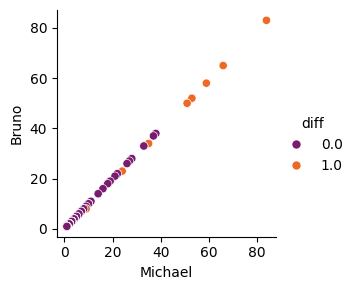

In [58]:
sns.relplot(data=comp_number_species, x='Michael', y='Bruno', height=3, hue='diff', palette='inferno')

In [88]:
final_byhrhabitat = final[['OTU', 'Habitat', 'Host']].value_counts().reset_index()[['OTU', 'Habitat']].value_counts().reset_index().pivot(index='OTU', columns='Habitat', values='count').fillna(0).reset_index()
final_byhrhabitat

Habitat,OTU,Crop,Edge,Oak,Wasteland
0,AEV1,0.0,0.0,1.0,0.0
1,AEYV,1.0,2.0,0.0,1.0
2,AGLV,0.0,1.0,0.0,0.0
3,ALaV,0.0,3.0,7.0,2.0
4,AMCV,0.0,1.0,0.0,1.0
...,...,...,...,...,...
153,YBMV,1.0,0.0,0.0,0.0
154,YMV,1.0,0.0,0.0,1.0
155,YSV,0.0,2.0,0.0,0.0
156,YoMV,1.0,5.0,9.0,12.0


In [98]:
comp_number_habitats = pd.merge(
    final_byhrhabitat.melt(id_vars=['OTU'], value_vars=['Crop', 'Edge', 'Oak', 'Wasteland']).rename(columns={'value':'Bruno'}), 
    hits_by_environment.rename(columns={'OTU reference': 'OTU'}).melt(id_vars=['OTU'], value_vars=['Crop', 'Edge', 'Oak', 'Wasteland']).rename(columns={'variable': 'Habitat', 'value':'Michael'}),
    left_on=['OTU', 'Habitat'], right_on=['OTU', 'Habitat']
)
comp_number_habitats['diff']  = comp_number_habitats['Michael'] - comp_number_habitats['Bruno']
comp_number_habitats

,OTU,Habitat,Bruno,Michael,diff
0,AEV1,Crop,0.0,0.0,0.0
1,AEYV,Crop,1.0,1.0,0.0
2,AGLV,Crop,0.0,0.0,0.0
3,ALaV,Crop,0.0,0.0,0.0
4,AMCV,Crop,0.0,0.0,0.0
...,...,...,...,...,...
627,YBMV,Wasteland,0.0,0.0,0.0
628,YMV,Wasteland,1.0,1.0,0.0
629,YSV,Wasteland,0.0,0.0,0.0
630,YoMV,Wasteland,12.0,12.0,0.0


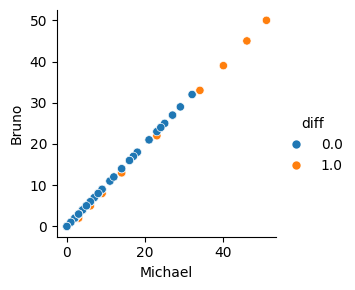

In [100]:
sns.relplot(data=comp_number_habitats, x='Michael', y='Bruno', hue='diff', height=3.0)